In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/customer_segmented.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1000, 10)


,name,age,gender,education,income,country,purchase_frequency,annual_spending,cluster,segment
0,Teresa Williams MD,42,Female,High School,53936,Slovenia,0.9,13227.120,1,Regular
1,Christine Myers,49,Female,Master,82468,Aruba,0.6,12674.040,0,Premium
2,Dwayne Moreno,55,Male,Bachelor,56941,Cyprus,0.3,5354.115,2,Budget
3,Amy Norton,24,Female,Bachelor,60651,Palau,0.2,2606.510,2,Budget
4,Tonya Adams,64,Male,Master,81884,Zambia,0.9,18984.780,0,Premium


In [2]:
features = [
    "age",
    "income",
    "purchase_frequency",
    "annual_spending"
]

X = df[features]
y = df["segment"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   age  income  purchase_frequency  annual_spending
0   42   53936                 0.9        13227.120
1   49   82468                 0.6        12674.040
2   55   56941                 0.3         5354.115
3   24   60651                 0.2         2606.510
4   64   81884                 0.9        18984.780

Target:
0    Regular
1    Premium
2     Budget
3     Budget
4    Premium
Name: segment, dtype: str


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 4)
Testing data: (200, 4)


In [4]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [5]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Make predictions on test data
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 0.9800
Test Accuracy: 98.00%


In [6]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

      Budget       1.00      0.97      0.98        89
     Premium       0.95      1.00      0.98        59
     Regular       0.98      0.98      0.98        52

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



In [7]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Premium", "Regular", "Budget"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[59  0  0]
 [ 1 51  0]
 [ 2  1 86]]


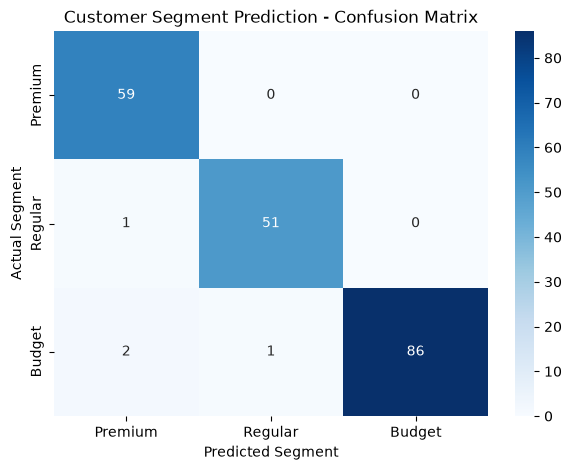

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Premium", "Regular", "Budget"],
    yticklabels=["Premium", "Regular", "Budget"]
)

plt.title("Customer Segment Prediction - Confusion Matrix")
plt.xlabel("Predicted Segment")
plt.ylabel("Actual Segment")

plt.show()

In [9]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:")
print(cv_scores)

print("\nMean cross-validation accuracy:")
print(f"{cv_scores.mean() * 100:.2f}%")

print("\nStandard deviation:")
print(f"{cv_scores.std() * 100:.2f}%")

Cross-validation scores:
[0.98  0.985 0.955 0.97  0.97 ]

Mean cross-validation accuracy:
97.20%

Standard deviation:
1.03%


In [10]:
import joblib

joblib.dump(model, "../data/customer_segmentation_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [11]:
def predict_customer_segment(age, income, purchase_frequency, annual_spending):
    
    customer = pd.DataFrame({
        "age": [age],
        "income": [income],
        "purchase_frequency": [purchase_frequency],
        "annual_spending": [annual_spending]
    })
    
    prediction = model.predict(customer)
    
    return prediction[0]

In [12]:
result = predict_customer_segment(
    age=30,
    income=1200000,
    purchase_frequency=0.8,
    annual_spending=150000
)

print("Predicted Customer Segment:", result)

Predicted Customer Segment: Premium


In [13]:
test_customers = [
    {
        "name": "Premium Customer",
        "age": 35,
        "income": 120000,
        "purchase_frequency": 0.9,
        "annual_spending": 18000
    },
    {
        "name": "Regular Customer",
        "age": 45,
        "income": 50000,
        "purchase_frequency": 0.7,
        "annual_spending": 12000
    },
    {
        "name": "Budget Customer",
        "age": 30,
        "income": 40000,
        "purchase_frequency": 0.2,
        "annual_spending": 4000
    }
]

for customer in test_customers:
    result = predict_customer_segment(
        customer["age"],
        customer["income"],
        customer["purchase_frequency"],
        customer["annual_spending"]
    )
    
    print(customer["name"], "→", result)

Premium Customer → Premium
Regular Customer → Regular
Budget Customer → Budget
